## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

---
## <u>Generate Synthetic Dataset — Binary</u>

Same reasoning as the regression comparison: `make_classification` isolates model differences from data quirks. `n_informative=12` of `20` features actually separate the two classes, `n_redundant=3` are linear combinations of informative ones (tests whether models handle redundancy well), `class_sep=1.0` keeps the classes genuinely overlapping rather than trivially separable.

In [2]:
X, y = make_classification(
    n_samples=100000,
    n_features=20,
    n_informative=12,
    n_redundant=3,
    n_classes=2,
    class_sep=1.0,
    random_state=42
)
X = pd.DataFrame(X)

---
## <u>Train Test Split</u>

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

---
## <u>Scale Features</u>

In [4]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## <u>Convert to PyTorch Tensors</u>

Binary: `y` needs `dtype=torch.float32` and `.view(-1,1)` -- shape must match the model's single output neuron, to pair correctly with `BCEWithLogitsLoss`.

In [5]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

---
## <u>Build TensorDataset & DataLoader</u>

In [6]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

---
## <u>Define ANN Model — Binary</u>

Output layer = 1 neuron, no activation (`BCEWithLogitsLoss` applies sigmoid internally). Architecture tapers toward the output (`64 -> 32 -> 1`), consistent with every build except the regression comparison's inverted one.

In [7]:
class ANN_Classifier(nn.Module):

    def __init__(self):
        super(ANN_Classifier, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # binary -- 1 output neuron
        )

    def forward(self, x):
        return self.model(x)

---
## <u>Compile the Model</u>

In [8]:
model = ANN_Classifier()

loss_func = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

In [9]:
epochs = 50
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_tensor = model(x_batch)
        batch_loss = loss_func(y_pred_tensor, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            y_pred_tensor = model(x_batch)
            batch_loss = loss_func(y_pred_tensor, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {avg_train_loss} & val loss = {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_binary_model.pt")

print("best model at epoch : ", best_epoch)

epoch 1/50 ==> train loss = 0.14467600599136204 & val loss = 0.0942820142313838
epoch 2/50 ==> train loss = 0.08382221901705489 & val loss = 0.07690839854329824
epoch 3/50 ==> train loss = 0.06997514621624723 & val loss = 0.07024405002221465
epoch 4/50 ==> train loss = 0.061337438901374115 & val loss = 0.060383977093547585
epoch 5/50 ==> train loss = 0.05577889914941043 & val loss = 0.05740837211702019
epoch 6/50 ==> train loss = 0.05204921042006463 & val loss = 0.05369854980222881
epoch 7/50 ==> train loss = 0.049456685739569364 & val loss = 0.056172542648762466
epoch 8/50 ==> train loss = 0.04737956410739571 & val loss = 0.0519380927529186
epoch 9/50 ==> train loss = 0.04608841492384672 & val loss = 0.050864829034917056
epoch 10/50 ==> train loss = 0.044910962677327915 & val loss = 0.050017333936318756
epoch 11/50 ==> train loss = 0.04366889618318528 & val loss = 0.049494970755651596
epoch 12/50 ==> train loss = 0.04319188286387361 & val loss = 0.05084045760910958
epoch 13/50 ==> tra

---
## <u>Plot ANN Loss Curves</u>

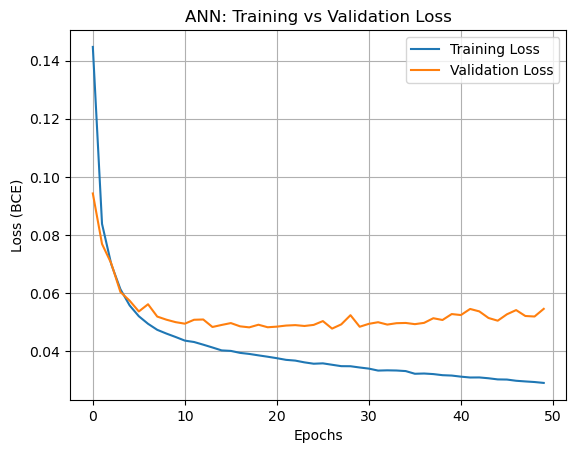

In [10]:
loss_df = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss (BCE)")
plt.title("ANN: Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint & Evaluate ANN</u>

Threshold-based decision, not `argmax` -- only 1 output neuron, nothing to compare it against within the row. `sigmoid` turns the raw logit into a probability, `>= 0.5` turns that into a hard 0/1 prediction.

In [11]:
model.load_state_dict(torch.load("best_binary_model.pt", weights_only=True))
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_tensor)                        # raw logits
    probabilities = torch.sigmoid(y_test_pred)                  # logits -> probabilities
    pred_classes = (probabilities >= 0.5).float()                # probabilities -> 0/1 predicted class

accuracy = accuracy_score(y_test_tensor.numpy(), pred_classes.numpy())
precision = precision_score(y_test_tensor.numpy(), pred_classes.numpy())
recall = recall_score(y_test_tensor.numpy(), pred_classes.numpy())
f1 = f1_score(y_test_tensor.numpy(), pred_classes.numpy())

print("--- ANN ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

--- ANN ---
Accuracy: 0.99095
Precision: 0.9913844920857544
Recall: 0.9904914422980683
F1 score: 0.9909377659840785


---
## <u>Logistic Regression</u>

In [5]:
lgr = LogisticRegression(max_iter=1000, random_state=42)
lgr.fit(X_train_scaled, y_train)
pred = lgr.predict(X_test_scaled)

print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 score:", f1_score(y_test, pred))

--- Logistic Regression ---
Accuracy: 0.8093
Precision: 0.8038366945400885
Recall: 0.8178360524472025
F1 score: 0.8107759476086525


---
## <u>Random Forest</u>

In [6]:
rf = RandomForestClassifier(n_estimators=101, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
pred = rf.predict(X_test_scaled)

print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 score:", f1_score(y_test, pred))

--- Random Forest ---
Accuracy: 0.9117
Precision: 0.9203720740059287
Recall: 0.9012110899809829
F1 score: 0.9106908061090321


---
## <u>Gradient Boosting</u>

In [7]:
gbr = GradientBoostingClassifier(n_estimators=101, max_depth=3, random_state=42)
gbr.fit(X_train_scaled, y_train)
pred = gbr.predict(X_test_scaled)

print("--- Gradient Boosting ---")
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 score:", f1_score(y_test, pred))

--- Gradient Boosting ---
Accuracy: 0.8981
Precision: 0.9048976682618878
Recall: 0.8895005504954459
F1 score: 0.8971330506763577


---
## <u>Report — Findings Summary</u>

See `ANN_vs_ML_Classification_Report.md` for the full write-up (covers both binary and multiclass cases).

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | 0.80 | 0.80 | 0.82 | 0.82 |
| Random Forest | 0.91 | 0.92 | 0.90 | 0.91 |
| Gradient Boosting | 0.89 | 0.90 | 0.88 | 0.89 |
| ANN | 0.99 | 0.99 | 0.99 | 0.99 |